In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv('animals3.csv')

In [3]:
df.head()

,Animal,Is_Mammal,Lives_In_Water,Has_4_Legs,Is_Predator,Is_Domestic,Can_Fly,Has_Fur,Has_Feathers,Has_Scales,Can_Climb_Trees,Is_Nocturnal,Has_Horns,Has_Stripes,Has_Trunk
0,Dog,1,0,1,1,1,0,1,0,0,0,0,0,0,0
1,Cat,1,0,1,1,1,0,1,0,0,1,1,0,0,0
2,Lion,1,0,1,1,0,0,1,0,0,0,0,0,0,0
3,Tiger,1,0,1,1,0,0,1,0,0,0,0,0,1,0
4,Elephant,1,0,1,0,0,0,0,0,0,0,0,0,0,1


In [4]:
X=df.drop('Animal',axis=1)
y=df['Animal']

In [5]:
# X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) #data too less to perform train test split

In [6]:
from sklearn.model_selection import GridSearchCV

In [7]:
rf = RandomForestClassifier(random_state=42)

In [8]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

In [9]:
from sklearn.model_selection import KFold

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

In [10]:
grid.fit(X,y)

GridSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [50, 100]},
             scoring='accuracy')

In [11]:
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [12]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 1.0


In [13]:
model=RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42
)

In [14]:
model.fit(X,y)

RandomForestClassifier(n_estimators=50, random_state=42)

In [15]:
y_pred=model.predict(X)

In [16]:
acc=accuracy_score(y,y_pred)
acc

1.0

In [17]:
duplicates = df.groupby(list(X.columns))['Animal'].nunique()
print(duplicates[duplicates > 1])

Series([], Name: Animal, dtype: int64)


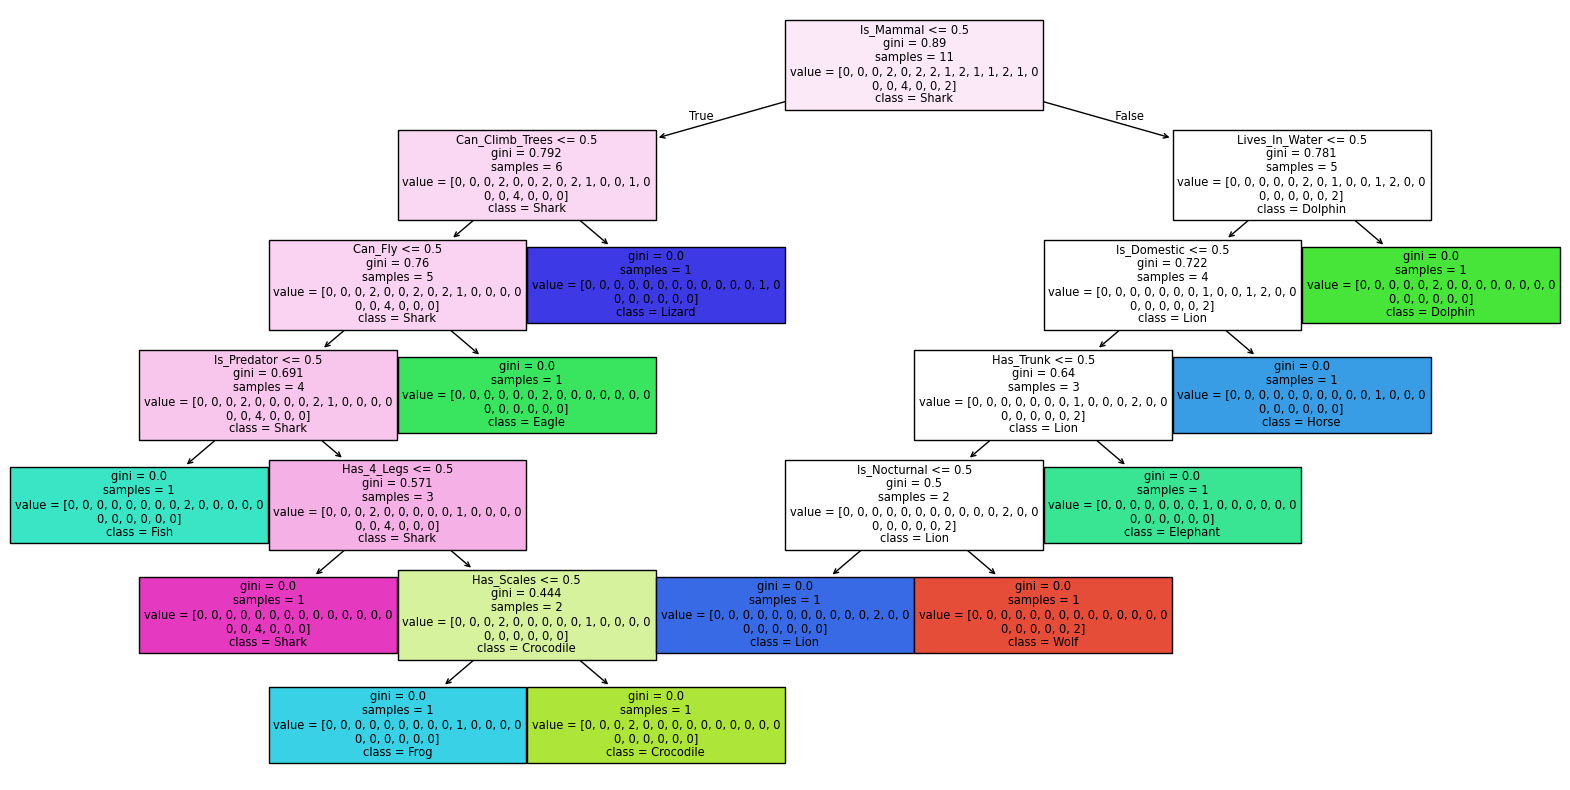

In [18]:
from sklearn.tree import plot_tree
tree = model.estimators_[0]
plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)
plt.show()

In [19]:
# Feature Importance
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False)

print(feat_imp)

Is_Predator        0.114287
Is_Domestic        0.104050
Has_4_Legs         0.096566
Has_Scales         0.088353
Can_Climb_Trees    0.084875
Is_Nocturnal       0.080541
Lives_In_Water     0.071154
Is_Mammal          0.066765
Can_Fly            0.064636
Has_Feathers       0.058983
Has_Fur            0.054038
Has_Stripes        0.044473
Has_Horns          0.043940
Has_Trunk          0.027341
dtype: float64


In [20]:
questions_map = {
    "Is_Mammal": "Is it a mammal?",
    "Lives_In_Water": "Does it live in water?",
    "Has_4_Legs": "Does it have 4 legs?",
    "Is_Predator": "Is it a predator?",
    "Is_Domestic": "Is it domestic?",
    "Can_Fly": "Can it fly?",
    "Has_Fur": "Does it have fur?",
    "Has_Feathers": "Does it have feathers?",
    "Has_Scales": "Does it have scales?",   
    "Can_Climb_Trees": "Can it climb trees?",
    "Is_Nocturnal": "Is it nocturnal (active at night)?",
    "Has_Horns": "Does it have horns?",
    "Has_Stripes": "Does it have stripes?",
    "Has_Trunk": "Does it have a trunk?"
}

In [31]:
import numpy as np

def play_game(model, X, threshold=0.75):
    print("\n🎮 Think of an animal... I will guess it!\n")

    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)[::-1]

    answers = [0]*len(X.columns)

    for step, i in enumerate(sorted_idx):
        col = X.columns[i]
        q = questions_map.get(col, col)

        ans = input(q + " (y/n): ").lower()

        if ans not in ["y", "n"]:
            print("Please answer y or n!")
            return

        answers[i] = 1 if ans == "y" else 0

        # checking confidence after each answer
        input_df = pd.DataFrame([answers], columns=X.columns)
        probs = model.predict_proba(input_df)[0]
        max_prob = max(probs)
        best_guess = model.classes_[np.argmax(probs)]

        if step >= 2:
            print(f"👉 Current best guess: {best_guess} ({round(max_prob*100,2)}%)")

        # Early Stop
        if max_prob >= threshold:
            print("\n🤖 I'm confident enough!")
            print(f"Final Guess: {best_guess} ({round(max_prob*100,2)}%)")
            return
            
    # fallback if not confident

    top_indices = np.argsort(probs)[::-1][:3]

    for i in top_indices:
        guess = model.classes_[i]
        ans = input(f"\n🤖 Is it {guess}? (y/n): ").lower()

        if ans == "y":
            print("🎉 Yay! I guessed it right!")
            return
        elif ans != "n":
            print("Please answer y or n!")
            return

    # if all guesses fail
    print("\n😅 I couldn't identify it. Maybe you can teach me next time!")

In [34]:
play_game(model,X)


🎮 Think of an animal... I will guess it!



Is it a predator? (y/n):  y
Is it domestic? (y/n):  y
Does it have 4 legs? (y/n):  y


👉 Current best guess: Frog (22.0%)


Does it have scales? (y/n):  n


👉 Current best guess: Frog (22.0%)


...

👉 Current best guess: Dog (26.0%)


Does it have a trunk? (y/n):  n


👉 Current best guess: Dog (26.0%)



🤖 Is it Tiger? (y/n):  y


🎉 Yay! I guessed it right!
